# Module 3 — Intent Classifier (Optimised 3-Stage Pipeline)
## RAG-Based Mental Health Support Chatbot


### Overview
This notebook builds an **Intent Classifier** that routes each user message to one of five intents and **supports multilingual inputs** across 20 languages.

| Intent | Description | System Action |
|---|---|---|
| `greeting` | Hello, hi, good morning… | Reply directly, no RAG |
| `goodbye` | Bye, see you, take care… | Reply directly, no RAG |
| `gratitude` | Thank you, thanks, I appreciate… | Reply directly, no RAG |
| `asking_mental_health_question` | Questions about anxiety, depression, therapy… | **Trigger RAG pipeline** |
| `out_of_scope` | Unrelated topics (weather, math, sports…) | Politely decline |

**Target language coverage:** English, Spanish, French, Arabic, Hindi, Japanese, Chinese, Russian, Portuguese, Turkish, Italian, German, Modern Greek, Dutch, Vietnamese, Swahili, Urdu, Polish, Bulgarian, Thai.

---

| Section | Description |
|---|---|
| 1. Configuration | Configure API keys, model names, thresholds, and intent labels |
| 2. Groq Client Initialisation | Set up the Groq client and verify connectivity |
| 3. Stage 1 - Rule-Based Keyword Matching | Fast multilingual keyword routing with false-positive guards |
| 4. Stage 2 - Multilingual Embedding Classification | Semantic similarity classification using sentence embeddings |
| 5. Stage 3 - LLM Fallback Classification | Few-shot LLM intent classification for ambiguous inputs |
| 6. Unified 3-Stage Classification Pipeline | Single entry point that cascades all stages |
| 7. Evaluation Dataset | Curated labeled dataset for evaluation |
| 8. Run Evaluation | Run the pipeline on the evaluation set |
| 9. Results Analysis | Metrics, confusion matrix, and plots |
| 9B. Stage 3 Few-shot vs Zero-shot Comparison | Compare few-shot and zero-shot performance |
| 10. System Router | Production routing layer for downstream actions |
| 11. Final Summary | End-to-end summary and outputs |
| Appendix - Design Decisions | Key choices and rationale |

### 3-Stage Optimised Pipeline

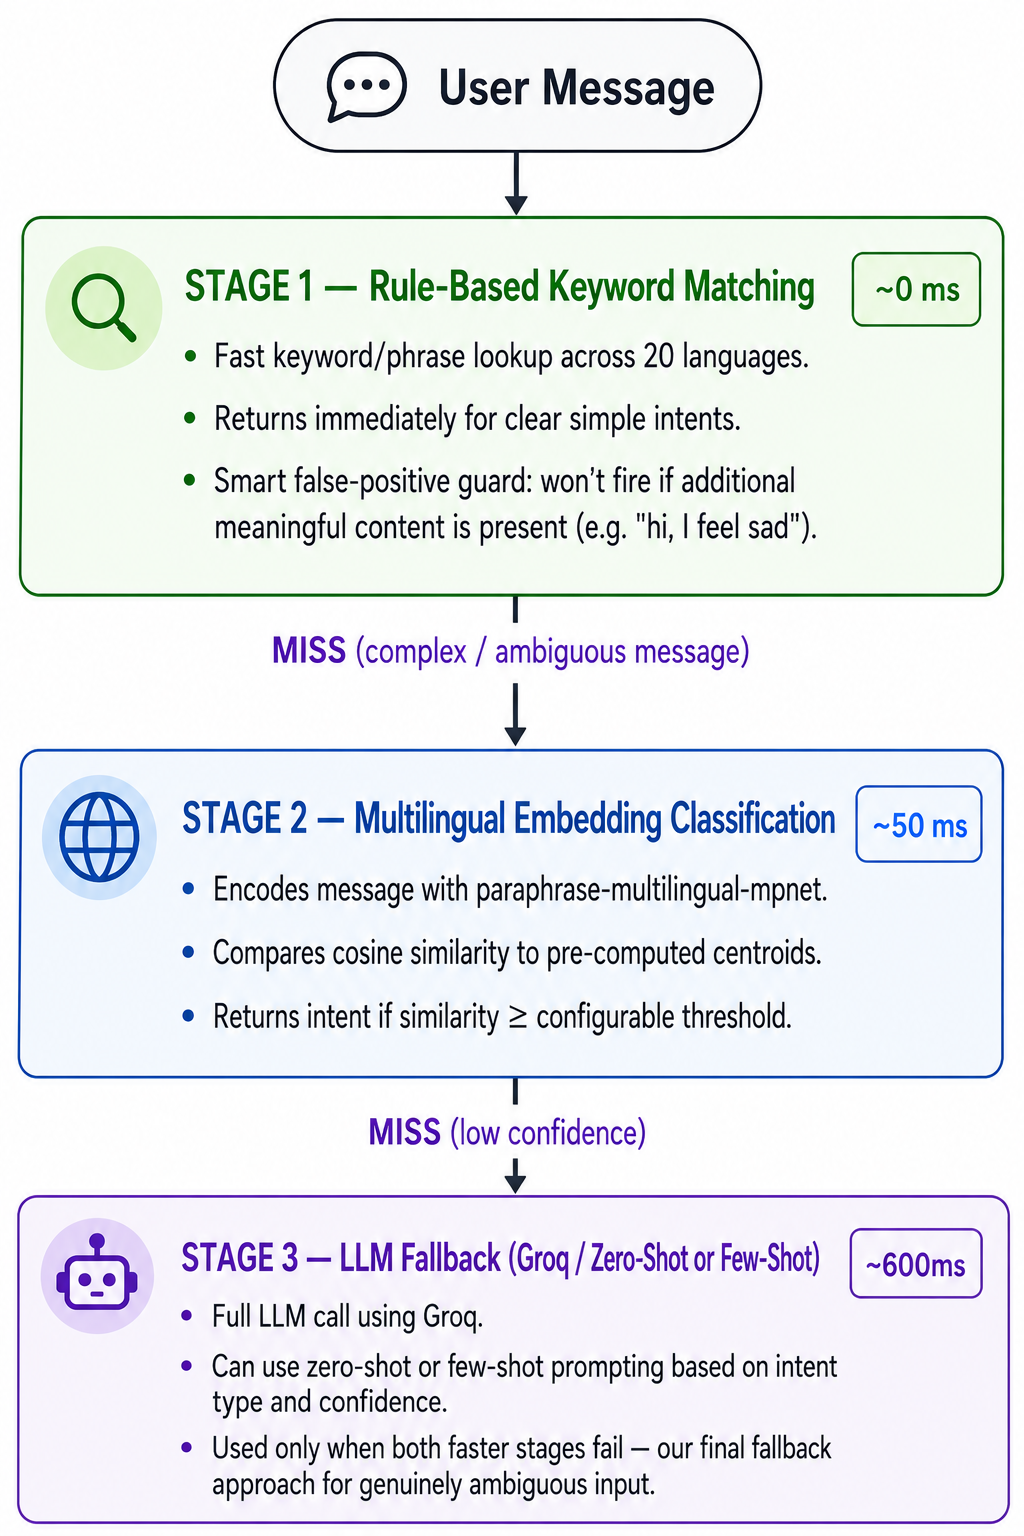

**Expected API call reduction:** ~70-85 % of real-world traffic resolves at Stage 1 or 2, meaning the expensive LLM is invoked only for truly ambiguous messages.


In [1]:
# Install required packages
# sentence-transformers added for Stage 2 multilingual embeddings
!pip install groq python-dotenv scikit-learn pandas numpy matplotlib seaborn tqdm sentence-transformers torch

In [2]:
import os
import json
import time
import re
from typing import Optional
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# Stage 2 — multilingual embeddings
from sentence_transformers import SentenceTransformer

# Stage 3 — LLM fallback
from groq import Groq
from dotenv import load_dotenv

load_dotenv()
print("✅ All packages loaded successfully.")


✅ All packages loaded successfully.


---
## 1. Configuration

In [3]:
# ─────────────────────────────────────────────────────────────────────────
# CONFIGURATION — edit only this cell
# ─────────────────────────────────────────────────────────────────────────

# ── Groq / LLM (Stage 3) ─────────────────────────────────────────────────
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError(
        "❌ GROQ_API_KEY not found.\n"
        "Set it in a .env file as: GROQ_API_KEY=gsk_xxxx\n"
        "Or set it directly in the cell above."
    )

MODEL_NAME = "llama-3.1-8b-instant"
# ── Embedding model (Stage 2) ─────────────────────────────────────────────
EMBEDDING_MODEL_NAME = "paraphrase-multilingual-mpnet-base-v2"

# Minimum cosine-similarity for Stage 2 to commit to an answer.
EMBEDDING_THRESHOLD = 0.7

# ── Intent labels ─────────────────────────────────────────────────────────
VALID_INTENTS = [
    "greeting",
    "goodbye",
    "gratitude",
    "asking_mental_health_question",
    "out_of_scope",
]

# Delay between LLM API calls to respect rate limits (seconds)
API_CALL_DELAY = 0.5

print("✅ Configuration loaded.")
print(f"   LLM model           : {MODEL_NAME}")
print(f"   Embedding model     : {EMBEDDING_MODEL_NAME}")
print(f"   Embedding threshold : {EMBEDDING_THRESHOLD}")
print(f"   Valid intents       : {VALID_INTENTS}")


✅ Configuration loaded.
   LLM model           : llama-3.1-8b-instant
   Embedding model     : paraphrase-multilingual-mpnet-base-v2
   Embedding threshold : 0.7
   Valid intents       : ['greeting', 'goodbye', 'gratitude', 'asking_mental_health_question', 'out_of_scope']


---
## 2. Groq Client Initialisation

In [4]:
# Initialise Groq client (used only by Stage 3)
groq_client = Groq(api_key=GROQ_API_KEY)

# Quick connectivity test
_test = groq_client.chat.completions.create(
    model=MODEL_NAME,
    messages=[{"role": "user", "content": "Reply with the single word: connected"}],
    max_tokens=10,
    temperature=0,
)
print(f"✅ Groq client connected.")
print(f"   Test response: {_test.choices[0].message.content.strip()}")

✅ Groq client connected.
   Test response: Connected


---
## 3. Stage 1 — Rule-Based Keyword Matching

The fastest and cheapest path. A hand-crafted dictionary maps individual
keywords and phrases in all 20 supported languages directly to an intent.

**False-positive guard:** After a keyword match, the function checks whether
the message contains *additional meaningful content* (mental health signals
or substantial extra words). If so, it yields to Stage 2/3 rather than
returning the keyword intent. This prevents, for example,
`"hi, I feel depressed"` from being misclassified as a greeting.


In [5]:
# ─────────────────────────────────────────────────────────────────────────
# KEYWORD RULES
# Structure: intent → language_code → [keyword/phrase, ...]
# All entries are lowercase; matching is case-insensitive.
#
# Language codes (ISO 639-1):
#   en=English  es=Spanish  fr=French   ar=Arabic   hi=Hindi
#   ja=Japanese zh=Chinese  ru=Russian  pt=Portuguese tr=Turkish
#   it=Italian  de=German   el=Greek    nl=Dutch    vi=Vietnamese
#   sw=Swahili  ur=Urdu     pl=Polish   bg=Bulgarian th=Thai
# ─────────────────────────────────────────────────────────────────────────

KEYWORD_RULES = {
    # ── GREETING ─────────────────────────────────────────────────────────
    "greeting": {
        "en": ["hi", "hello", "hey", "howdy", "greetings", "good morning",
               "good afternoon", "good evening", "good day", "sup",
               "what's up", "whats up", "yo", "hiya", "ello", "good to see you"],
        "es": ["hola", "buenos días", "buenos dias", "buenas tardes",
               "buenas noches", "buenas", "qué tal", "que tal", "buen día"],
        "fr": ["bonjour", "bonsoir", "salut", "coucou", "bonne journée",
               "bonne matinée"],
        "ar": ["مرحبا", "مرحباً", "السلام عليكم", "أهلا", "أهلاً",
               "صباح الخير", "مساء الخير", "هلا", "أهلاً وسهلاً"],
        "hi": ["नमस्ते", "नमस्कार", "हेलो", "प्रणाम", "राम राम",
               "सुप्रभात", "शुभ संध्या"],
        "ja": ["こんにちは", "こんばんは", "おはよう", "おはようございます",
               "やあ", "ハロー", "よう", "どうも"],
        "zh": ["你好", "您好", "嗨", "早上好", "早", "哈喽", "大家好",
               "晚上好", "下午好"],
        "ru": ["привет", "здравствуйте", "здравствуй", "добрый день",
               "доброе утро", "добрый вечер", "хай", "хей", "приветствую"],
        "pt": ["olá", "oi", "bom dia", "boa tarde", "boa noite", "alô",
               "salve", "e aí"],
        "tr": ["merhaba", "selam", "günaydın", "iyi günler", "iyi akşamlar",
               "selamlar", "n'aber"],
        "it": ["ciao", "buongiorno", "buonasera", "salve", "buon pomeriggio"],
        "de": ["hallo", "guten morgen", "guten tag", "guten abend", "servus",
               "moin", "tach"],
        "el": ["γεια", "γεια σου", "γεια σας", "καλημέρα", "καλησπέρα",
               "χαίρετε"],
        "nl": ["hallo", "hoi", "goedendag", "goedemorgen", "goedemiddag",
               "goedenavond", "hee"],
        "vi": ["xin chào", "chào", "chào buổi sáng", "chào buổi chiều",
               "chào mừng", "chào bạn"],
        "sw": ["habari", "jambo", "hujambo", "mambo", "salam", "shikamoo",
               "karibu", "habari yako"],
        "ur": ["ہیلو", "السلام علیکم", "آداب", "سلام", "ادب",
               "صبح بخیر", "شام بخیر"],
        "pl": ["cześć", "dzień dobry", "hej", "siema", "witaj", "witajcie",
               "dobry wieczór"],
        "bg": ["здравей", "здравейте", "добро утро", "добър ден",
               "добър вечер", "хей"],
        "th": ["สวัสดี", "สวัสดีครับ", "สวัสดีค่ะ", "หวัดดี",
               "ดีจ้า", "ดีครับ", "ดีค่ะ"],
    },

    # ── GOODBYE ──────────────────────────────────────────────────────────
    "goodbye": {
        "en": ["bye", "goodbye", "farewell", "see you", "see ya", "take care",
               "later", "gotta go", "signing off", "good night", "ttyl", "cya",
               "have a good one", "until next time", "so long", "tata",
               "ta-ta", "cheerio", "catch you later", "talk later"],
        "es": ["adiós", "adios", "hasta luego", "nos vemos", "chao", "chau",
               "hasta pronto", "hasta mañana", "que te vaya bien"],
        "fr": ["au revoir", "à bientôt", "adieu", "bonne nuit", "à plus",
               "à plus tard", "à la prochaine"],
        "ar": ["مع السلامة", "وداعاً", "وداعا", "إلى اللقاء", "باي",
               "تصبح على خير", "الى اللقاء"],
        "hi": ["अलविदा", "फिर मिलेंगे", "टाटा", "बाय", "शुभ रात्रि"],
        "ja": ["さようなら", "バイバイ", "またね", "じゃあね", "お休み",
               "またあした", "では", "失礼します"],
        "zh": ["再见", "拜拜", "再会", "晚安", "回头见", "下次见",
               "先走了", "再联系"],
        "ru": ["до свидания", "пока", "прощай", "до встречи",
               "всего хорошего", "спокойной ночи", "увидимся"],
        "pt": ["tchau", "adeus", "até logo", "até mais", "boa noite",
               "até amanhã", "até breve"],
        "tr": ["güle güle", "hoşçakal", "görüşürüz", "iyi geceler",
               "bay bay", "görüşmek üzere"],
        "it": ["arrivederci", "addio", "a presto", "buonanotte",
               "ci vediamo", "a domani"],
        "de": ["auf wiedersehen", "tschüss", "tschüssi", "bis bald",
               "gute nacht", "bis dann", "bis später"],
        "el": ["αντίο", "τα λέμε", "αντίο σας", "καληνύχτα",
               "εις το επανιδείν"],
        "nl": ["tot ziens", "doei", "dag", "tot later", "goedenacht",
               "tot snel", "tot morgen"],
        "vi": ["tạm biệt", "hẹn gặp lại", "chào tạm biệt",
               "chúc ngủ ngon", "bái bai"],
        "sw": ["kwa heri", "kwaheri", "tutaonana", "lala salama",
               "usiku mwema"],
        "ur": ["خدا حافظ", "اللہ حافظ", "الوداع", "پھر ملیں گے",
               "بائے", "شب بخیر"],
        "pl": ["do widzenia", "pa", "na razie", "dobranoc",
               "do zobaczenia"],
        "bg": ["довиждане", "чао", "до скоро", "лека нощ",
               "ще се видим"],
        "th": ["ลาก่อน", "บาย", "แล้วเจอกัน", "ราตรีสวัสดิ์", "ฝันดี"],
    },

    # ── GRATITUDE ─────────────────────────────────────────────────────────
    "gratitude": {
        "en": ["thanks", "thank you", "thank u", "thx", "ty", "cheers",
               "grateful", "i appreciate", "much appreciated", "many thanks",
               "ta", "thanks a lot", "thank you very much", "so thankful"],
        "es": ["gracias", "muchas gracias", "mil gracias",
               "te lo agradezco", "muy agradecido", "muy agradecida"],
        "fr": ["merci", "merci beaucoup", "je vous remercie",
               "je te remercie", "grand merci", "merci infiniment"],
        "ar": ["شكرا", "شكراً", "شكرا جزيلا", "ممنون", "متشكر",
               "جزاك الله خيراً", "الله يعطيك العافية", "مشكور"],
        "hi": ["धन्यवाद", "शुक्रिया", "थैंक यू", "आभार",
               "बहुत बहुत धन्यवाद"],
        "ja": ["ありがとう", "ありがとうございます", "どうもありがとう",
               "感謝します", "ありがとうございました"],
        "zh": ["谢谢", "谢谢你", "谢谢您", "多谢", "非常感谢", "感谢",
               "太感谢了"],
        "ru": ["спасибо", "благодарю", "большое спасибо",
               "благодарен", "благодарна"],
        "pt": ["obrigado", "obrigada", "muito obrigado", "muito obrigada",
               "agradecido", "agradecida"],
        "tr": ["teşekkürler", "teşekkür ederim", "sağ ol",
               "çok teşekkürler", "minnettarım"],
        "it": ["grazie", "grazie mille", "ti ringrazio", "vi ringrazio",
               "mille grazie", "grazie tante"],
        "de": ["danke", "danke schön", "vielen dank", "herzlichen dank",
               "dankeschön", "besten dank"],
        "el": ["ευχαριστώ", "ευχαριστώ πολύ", "σε ευχαριστώ",
               "σας ευχαριστώ"],
        "nl": ["dank je", "dank u", "dank je wel", "bedankt",
               "hartelijk dank", "ontzettend bedankt"],
        "vi": ["cảm ơn", "cảm ơn bạn", "cảm ơn nhiều",
               "xin cảm ơn", "cảm ơn rất nhiều"],
        "sw": ["asante", "asante sana", "nashukuru", "shukrani",
               "asante kwa msaada"],
        "ur": ["شکریہ", "بہت شکریہ", "ممنون", "آپ کا شکریہ"],
        "pl": ["dziękuję", "dziękuję bardzo", "dzięki",
               "wielkie dzięki", "bardzo dziękuję"],
        "bg": ["благодаря", "благодаря много", "благодарен съм",
               "мерси", "благодарна съм"],
        "th": ["ขอบคุณ", "ขอบคุณมาก", "ขอบใจ", "ขอบพระคุณ",
               "ขอบคุณครับ", "ขอบคุณค่ะ"],
    },
}

# ─────────────────────────────────────────────────────────────────────────
# MENTAL HEALTH SIGNALS
# High-signal words/phrases used to detect meaningful co-occurring content
# that would make a simple keyword match insufficient as a classification.
# Covers all 20 supported languages.
# ─────────────────────────────────────────────────────────────────────────

MENTAL_HEALTH_SIGNALS = {
    # English
    "anxiety", "anxious", "depressed", "depression", "stress", "stressed",
    "panic", "therapy", "therapist", "mental health", "suicidal", "self-harm",
    "burnout", "lonely", "loneliness", "grief", "trauma", "overwhelmed",
    "hopeless", "empty", "exhausted", "sad", "fear", "worried", "worry",
    "crying", "helpless", "worthless", "numb", "ptsd", "ocd", "adhd",
    "mood", "bipolar", "psychologist", "psychiatrist", "counseling",
    "counselor", "insomnia", "sleeping problems", "eating disorder",
    # Spanish
    "ansiedad", "depresión", "depresion", "estresado", "estrés", "estres",
    "terapia", "salud mental", "pánico", "panico", "angustia", "soledad",
    "tristeza", "agotado", "desesperado", "psicólogo", "burnout",
    # French
    "anxiété", "dépression", "stress", "thérapie", "panique",
    "santé mentale", "épuisement", "tristesse", "seul", "désespoir",
    "peur", "déprimé", "psychologue", "angoisse",
    # Arabic
    "قلق", "اكتئاب", "ضغط", "علاج نفسي", "نفسي", "حزن", "وحدة",
    "يأس", "خوف", "بكاء", "انهيار", "مشكلة نفسية", "معالج",
    # Hindi
    "चिंता", "तनाव", "अवसाद", "मानसिक", "घबराहट", "डर", "अकेलापन",
    "रोना", "निराशा", "मनोचिकित्सक",
    # Japanese
    "不安", "うつ", "ストレス", "療法", "パニック", "メンタル",
    "孤独", "恐怖", "疲労", "睡眠", "カウンセリング", "自傷",
    # Chinese
    "焦虑", "抑郁", "压力", "治疗", "恐慌", "心理", "孤独", "恐惧",
    "疲惫", "失眠", "心理咨询", "创伤",
    # Russian
    "тревога", "депрессия", "стресс", "терапия", "паника", "психическ",
    "одинок", "страх", "усталость", "бессонница", "психолог", "горе",
    # Portuguese
    "ansiedade", "depressão", "depressao", "estresse", "terapia", "pânico",
    "panico", "saúde mental", "solidão", "medo", "tristeza",
    "exausto", "desespero", "psicólogo",
    # Turkish
    "kaygı", "kaygi", "depresyon", "stres", "terapi", "panik",
    "ruh sağlığı", "yalnız", "korku", "yorgunluk", "uykusuzluk",
    # Italian
    "ansia", "depressione", "terapia", "panico", "salute mentale",
    "solitudine", "paura", "esaurito", "disperato", "psicologo",
    # German
    "angst", "depression", "therapie", "panik",
    "einsamkeit", "trauer", "erschöpft", "schlaflosigkeit", "psychologe",
    # Greek
    "άγχος", "κατάθλιψη", "στρες", "θεραπεία", "μοναξιά",
    "φόβος", "εξάντληση", "ψυχολόγος",
    # Dutch
    "depressie", "therapie", "paniek", "eenzaamheid",
    "verdriet", "uitgeput", "psycholoog", "slaapproblemen",
    # Vietnamese
    "lo lắng", "trầm cảm", "căng thẳng", "trị liệu", "cô đơn",
    "sợ hãi", "kiệt sức", "tâm lý",
    # Swahili
    "wasiwasi", "msongo", "huzuni", "upweke", "hofu", "uchovu",
    "afya ya akili",
    # Urdu
    "پریشانی", "ذہنی", "تناؤ", "ڈپریشن", "اکیلاپن", "خوف",
    "تھکاوٹ", "نیند", "نفسیات",
    # Polish
    "lęk", "depresja", "stres", "terapia", "panika", "samotność",
    "smutek", "wyczerpanie", "psycholog",
    # Bulgarian
    "тревожност", "депресия", "стрес", "терапия", "паника", "самота",
    "страх", "умора", "психолог", "безсъние",
    # Thai
    "วิตกกังวล", "ซึมเศร้า", "ความเครียด", "บำบัด", "โดดเดี่ยว",
    "กลัว", "เหนื่อย", "นักจิตวิทยา",
}

print("✅ Keyword rules loaded.")
print(f"   Intents covered       : {list(KEYWORD_RULES.keys())}")
total_kws = sum(len(kws) for lang in KEYWORD_RULES.values() for kws in lang.values())
print(f"   Total keywords/phrases: {total_kws}")
print(f"   Mental health signals : {len(MENTAL_HEALTH_SIGNALS)}")


✅ Keyword rules loaded.
   Intents covered       : ['greeting', 'goodbye', 'gratitude']
   Total keywords/phrases: 413
   Mental health signals : 223


In [6]:
# ─────────────────────────────────────────────────────────────────────────
# STAGE 1 — Helper functions
# ─────────────────────────────────────────────────────────────────────────

def _build_keyword_lookup() -> dict:
    """
    Flatten KEYWORD_RULES into a single dict: keyword_lowercase → intent.
    Longer phrases take priority (sorted longest-first during matching).
    """
    lookup = {}
    for intent, lang_dict in KEYWORD_RULES.items():
        for _lang, keywords in lang_dict.items():
            for kw in keywords:
                lookup[kw.lower()] = intent
    return lookup

_KEYWORD_LOOKUP = _build_keyword_lookup()


def _keyword_in_text(keyword: str, text: str) -> bool:
    """
    Match a keyword against text using:
      • Word-boundary regex  for ASCII keywords   (prevents 'hi' matching 'therapist')
      • Substring match      for non-ASCII tokens  (CJK, Arabic, Devanagari, etc.)
    """
    if all(ord(c) < 128 for c in keyword):
        pattern = r'(?<![a-z0-9])' + re.escape(keyword) + r'(?![a-z0-9])'
        return bool(re.search(pattern, text, re.IGNORECASE))
    else:
        return keyword in text


def _prune_overlapping_matches(matched: dict[str, list]) -> dict[str, list]:
    """
    Remove shorter keyword matches that are contained inside longer phrases.
    Prevents cases like 'see you' overriding 'good to see you'.
    """
    if not matched:
        return matched

    all_matches = [(kw, intent) for intent, kws in matched.items() for kw in kws]
    all_matches.sort(key=lambda x: len(x[0]), reverse=True)

    kept: list[tuple[str, str]] = []
    for kw, intent in all_matches:
        kw_lower = kw.lower()
        if any(kw_lower != kept_kw and kw_lower in kept_kw for kept_kw, _ in kept):
            continue
        kept.append((kw_lower, intent))

    pruned: dict[str, list] = {}
    for kw, intent in kept:
        pruned.setdefault(intent, []).append(kw)

    return pruned


def _looks_like_code_or_noise(message: str) -> bool:
    """
    Detect code-like inputs, translation requests, or gibberish that should
    be treated as out_of_scope.
    """
    msg = message.strip()
    if not msg:
        return True

    msg_lower = msg.lower()
    if "translate" in msg_lower or "translation" in msg_lower:
        language_names = (
            "english", "spanish", "french", "arabic", "hindi", "japanese",
            "chinese", "russian", "portuguese", "turkish", "italian", "german",
            "greek", "dutch", "vietnamese", "swahili", "urdu", "polish",
            "bulgarian", "thai",
        )
        if any(lang in msg_lower for lang in language_names):
            return True

    code_regexes = [
        r"\bprint\s*\(",
        r"\bconsole\.log\s*\(",
        r"\bdef\s+\w+\s*\(",
        r"\bimport\s+\w+",
        r"\bfrom\s+\w+\s+import\s+\w+",
        r"\bselect\b.+\bfrom\b",
    ]
    if any(re.search(rx, msg_lower) for rx in code_regexes):
        return True

    if re.search(r"[{}\[\]]", msg):
        return True

    # Gibberish heuristic: long single ASCII token with very low vowel ratio
    if all(ord(c) < 128 for c in msg):
        tokens = re.findall(r"[a-zA-Z]+", msg)
        if len(tokens) == 1:
            token = tokens[0]
            if len(token) >= 12:
                vowel_ratio = sum(ch in "aeiouy" for ch in token.lower()) / len(token)
                if vowel_ratio < 0.25:
                    return True

    return False


def _has_additional_meaningful_content(message: str, matched_keywords: list) -> bool:
    """
    Returns True when the message contains substantial content BEYOND the
    matched keywords, indicating a complex query the keyword stage should not
    short-circuit.

    Two independent checks (either triggers a True):
      1. Mental-health signal: any MENTAL_HEALTH_SIGNALS word appears in the message.
      2. Substantial residual: after stripping matched keywords, ≥ 4 meaningful
         tokens (len > 2) remain.

    Example:
        message = "hi, I feel depressed"
        matched_keywords = ["hi"]
        → "depressed" is a mental health signal → returns True → keyword stage yields
    """
    msg_lower = message.lower()

    # Check 1: mental health signal present anywhere in the message
    for signal in MENTAL_HEALTH_SIGNALS:
        if signal in msg_lower:
            return True

    # Check 2: substantial residual after stripping matched keywords
    residual = msg_lower
    for kw in matched_keywords:
        residual = residual.replace(kw.lower(), " ")

    residual = re.sub(r'[^\w\s]', ' ', residual)
    residual = re.sub(r'\s+', ' ', residual).strip()

    # Filter tokens with len > 2 to exclude articles, prepositions, etc.
    meaningful_tokens = [t for t in residual.split() if len(t) > 2]
    if len(meaningful_tokens) >= 4:
        return True

    return False


def rule_based_classify(message: str) -> Optional[dict]:
    """
    Stage 1: Rule-based keyword matching.

    Algorithm:
      1. Scan all keywords longest-first (multi-word phrases preferred over subwords).
      2. Collect matched intents and keywords.
      3. If additional meaningful content exists, yield to Stage 2/3.
      4. Priority resolution when multiple intents co-occur:
             goodbye  > gratitude  (e.g. "thanks, bye!")
             gratitude > greeting
      5. Return a result dict, or None if this stage cannot commit.

    Returns:
        dict {intent, confidence, stage, matched_keywords, latency_ms} or None.
    """
    t0 = time.time()

    if _looks_like_code_or_noise(message):
        return {
            "intent":           "out_of_scope",
            "confidence":       0.8,
            "stage":            "rule_based",
            "matched_keywords": [],
            "latency_ms":       int((time.time() - t0) * 1000),
        }

    msg_lower = message.lower().strip()

    # Scan longest-first to prefer specific phrases over sub-words
    matched: dict[str, list] = {}
    for keyword in sorted(_KEYWORD_LOOKUP.keys(), key=len, reverse=True):
        intent = _KEYWORD_LOOKUP[keyword]
        if _keyword_in_text(keyword, msg_lower):
            matched.setdefault(intent, []).append(keyword)

    if not matched:
        return None   # No keyword matched → Stage 2

    matched = _prune_overlapping_matches(matched)
    if not matched:
        return None   # Overlap pruning removed everything → Stage 2

    all_matched = [kw for kws in matched.values() for kw in kws]

    # ── False-positive guard ──────────────────────────────────────────────
    if _has_additional_meaningful_content(message, all_matched):
        return None   # Complex message → Stage 2

    # ── Priority resolution ───────────────────────────────────────────────
    if "goodbye" in matched:
        resolved = "goodbye"
    elif "gratitude" in matched:
        resolved = "gratitude"
    elif "greeting" in matched:
        resolved = "greeting"
    else:
        resolved = next(iter(matched))

    return {
        "intent":           resolved,
        "confidence":       0.95,
        "stage":            "rule_based",
        "matched_keywords": matched.get(resolved, []),
        "latency_ms":       int((time.time() - t0) * 1000),
    }


print("✅ Stage 1 functions defined.")
print(f"   Keyword lookup size : {len(_KEYWORD_LOOKUP)} entries")


✅ Stage 1 functions defined.
   Keyword lookup size : 408 entries


### Stage 1 — Quick Tests

In [7]:
stage1_tests = [
    # ── Should match (clean keyword, no extra content) ────────────────────
    ("hi",                                  "greeting",  True),
    ("Hello!",                              "greeting",  True),
    ("Hola",                                "greeting",  True),
    ("مرحبا",                               "greeting",  True),
    ("नमस्ते",                              "greeting",  True),
    ("こんにちは",                           "greeting",  True),
    ("你好",                                 "greeting",  True),
    ("Привет",                              "greeting",  True),
    ("Merhaba",                             "greeting",  True),
    ("Γεια σου",                            "greeting",  True),
    ("สวัสดีครับ",                          "greeting",  True),
    ("Habari",                              "greeting",  True),
    ("xin chào",                            "greeting",  True),
    ("Hey there, good to see you.",         "greeting",  True),
    ("bye",                                 "goodbye",   True),
    ("Goodbye!",                            "goodbye",   True),
    ("مع السلامة",                          "goodbye",   True),
    ("再见",                                 "goodbye",   True),
    ("Kwa heri",                            "goodbye",   True),
    ("Auf Wiedersehen",                     "goodbye",   True),
    ("thanks",                              "gratitude", True),
    ("Thank you!",                          "gratitude", True),
    ("شكرا",                                "gratitude", True),
    ("ありがとう",                           "gratitude", True),
    ("ขอบคุณมาก",                           "gratitude", True),
    ("Thanks for everything, bye.",         "goodbye",   True),   # priority: goodbye > gratitude
    # ── Should short-circuit to out_of_scope ──────────────────────────────
    ("print('hello world')",                "out_of_scope", True),
    ("xhsjdhsajdhajsdhjas",                 "out_of_scope", True),
    ("Can you translate this to French?",   "out_of_scope", True),
    # ── Should NOT match (meaningful additional content detected) ─────────
    ("hi, I feel depressed",                None,        False),  # mental health signal
    ("Hello, I'm struggling with anxiety",  None,        False),  # mental health signal
    ("thanks but I still feel anxious",     None,        False),  # mental health signal
    ("bye, this therapy session helped",    None,        False),  # mental health signal
    ("hi, how do I cope with stress?",      None,        False),  # mental health signal
    ("hello everyone, let me explain something very important today", None, False),  # too many residual words
]

print(f"{'Message':<55} {'Expected':<12} {'Got':<12} {'Stage':<12} {'OK?'}")
print("─" * 100)
ok_count = 0
for msg, expected_intent, should_match in stage1_tests:
    result = rule_based_classify(msg)
    got_intent = result["intent"] if result else None
    got_stage  = result["stage"]  if result else "—"
    matched    = (got_intent == expected_intent)
    if matched: ok_count += 1
    icon   = "✅" if matched else "❌"
    exp_str = expected_intent or "None (yield)"
    got_str = got_intent      or "None (yield)"
    print(f"{msg:<55} {exp_str:<12} {got_str:<12} {got_stage:<12} {icon}")

print()
print(f"Stage 1 tests passed: {ok_count}/{len(stage1_tests)}")


Message                                                 Expected     Got          Stage        OK?
────────────────────────────────────────────────────────────────────────────────────────────────────
hi                                                      greeting     greeting     rule_based   ✅
Hello!                                                  greeting     greeting     rule_based   ✅
Hola                                                    greeting     greeting     rule_based   ✅
مرحبا                                                   greeting     greeting     rule_based   ✅
नमस्ते                                                  greeting     greeting     rule_based   ✅
こんにちは                                                   greeting     greeting     rule_based   ✅
你好                                                      greeting     greeting     rule_based   ✅
Привет                                                  greeting     greeting     rule_based   ✅
Merhaba                 

---
## 4. Stage 2 — Multilingual Embedding Classification

When Stage 1 cannot commit, we use **multilingual sentence embeddings**
(`paraphrase-multilingual-mpnet-base-v2`) for semantic similarity classification:

1. **Pre-compute intent centroids** — encode exemplar sentences per intent and average their embeddings. Done once at startup.
2. **Encode the query** — embed the user message with the same model.
3. **Cosine similarity** — compare query embedding to each intent centroid.
4. **Threshold gate** — if highest similarity ≥ `EMBEDDING_THRESHOLD`, return that intent. Otherwise yield to Stage 3.

This handles most real-world messages across all 20 languages with **no LLM API call**.


In [8]:
# ─────────────────────────────────────────────────────────────────────────
# Load multilingual embedding model
# ─────────────────────────────────────────────────────────────────────────

print(f"Loading embedding model: {EMBEDDING_MODEL_NAME}")
print("First run will download ~420 MB — progress bar will appear below.")
print("-" * 60)

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

# Warmup: force full weight initialisation now so the centroid cell is pure computation with no hidden download lag.
print("\nWarming up model ...")
_ = embedding_model.encode(["warmup"], show_progress_bar=False)
print("✅ Embedding model ready.")

# ─────────────────────────────────────────────────────────────────────────
# INTENT EXEMPLARS
# ─────────────────────────────────────────────────────────────────────────

INTENT_EXEMPLARS = {
    "greeting": [
        "Hello there!", "Hi, how are you?", "Good morning!", "Hey, nice to meet you",
        "Greetings!", "Hey! Good to see you", "Hi, I'm new here",
        "Hola", "Bonjour", "مرحبا", "नमस्ते", "こんにちは",
        "你好", "Привет", "Merhaba", "Ciao", "Hallo",
        "Γεια σου", "สวัสดีครับ", "Habari",
    ],
    "goodbye": [
        "Goodbye!", "See you later!", "Take care!", "Bye bye", "I have to go now",
        "Until next time", "Farewell, and thanks", "Goodnight everyone",
        "Adiós", "Au revoir", "مع السلامة", "再见", "До свидания",
        "Tschüss", "Arrivederci", "Kwa heri", "さようなら", "Até logo",
        "Do widzenia", "ลาก่อน",
    ],
    "gratitude": [
        "Thank you so much!", "Thanks a lot!", "I really appreciate it",
        "You've been very helpful, thanks!", "I'm grateful for your support",
        "Thanks, that was very useful", "I appreciate your help enormously",
        "Gracias", "Merci beaucoup", "شكرا", "谢谢", "Спасибо",
        "Danke schön", "Grazie mille", "ありがとうございます",
        "Dziękuję bardzo", "ขอบคุณมาก", "Asante sana",
    ],
    "asking_mental_health_question": [
        "I've been feeling very anxious lately, what should I do?",
        "How do I deal with depression?",
        "I'm struggling with panic attacks",
        "Can you help me understand my stress?",
        "I feel hopeless and don't know what to do",
        "What therapy techniques help with anxiety?",
        "I've been having suicidal thoughts",
        "I feel burned out and exhausted all the time",
        "I'm so lonely and nobody understands me",
        "Is it normal to feel empty and numb?",
        "I can't sleep because of my anxiety",
        "Me siento muy deprimido, ¿qué hago?",
        "Je souffre d'anxiété sévère",
        "أشعر بالاكتئاب الشديد",
        "我感到非常焦虑，晚上睡不好",
        "У меня депрессия уже несколько месяцев",
        "Ich habe Angst und weiß nicht was ich tun soll",
        "Mam ataki paniki w pracy",
        "Tükenmiş hissediyorum ve bunun üstesinden gelemiyorum",
        "Continuo a sentirmi ansioso, cosa posso fare?",
        "Hi, I've been struggling with depression a lot lately",
    ],
    "out_of_scope": [
        "What is the capital of France?",
        "How do I code in Python?",
        "What's the weather today?",
        "Tell me a joke",
        "What are the best stocks to invest in?",
        "Can you help me with my homework?",
        "今天天气怎么样",
        "¿Cuál es la capital de España?",
        "Quel est le prix du bitcoin?",
        "asdkjhaskdjh",
        "2+2=?",
        "SELECT * FROM users",
        "Book me a flight to London",
        "Who is the president of France?",
    ],
}

print(f"\n✅ Intent exemplars defined.")
for intent, exs in INTENT_EXEMPLARS.items():
    print(f"   {intent:<35} → {len(exs)} exemplars")


Loading embedding model: paraphrase-multilingual-mpnet-base-v2
First run will download ~420 MB — progress bar will appear below.
------------------------------------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Warming up model ...
✅ Embedding model ready.

✅ Intent exemplars defined.
   greeting                            → 20 exemplars
   goodbye                             → 20 exemplars
   gratitude                           → 18 exemplars
   asking_mental_health_question       → 21 exemplars
   out_of_scope                        → 14 exemplars


In [9]:
# ─────────────────────────────────────────────────────────────────────────
# Pre-compute intent centroids (done ONCE at startup)
# ─────────────────────────────────────────────────────────────────────────

print("Step 1/2 — Encoding all exemplars in one batched call ...")
print(f"           Total sentences to encode: "
      f"{sum(len(v) for v in INTENT_EXEMPLARS.values())}")
print()

# Flatten all exemplars into one list, track which intent each belongs to
all_exemplars = []
intent_sizes  = {}
for intent, exemplars in INTENT_EXEMPLARS.items():
    intent_sizes[intent] = len(exemplars)
    all_exemplars.extend(exemplars)

# Single encode call — tqdm bar shows sentence-level progress
all_embeddings = embedding_model.encode(
    all_exemplars,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=32,
)

# Step 2: Slice embeddings back per intent and compute centroids
print("\nStep 2/2 — Computing per-intent centroids ...")
INTENT_CENTROIDS = {}
idx = 0

for intent in tqdm(intent_sizes, desc="Centroids", unit="intent"):
    size     = intent_sizes[intent]
    chunk    = all_embeddings[idx : idx + size]   # shape: (n_exemplars, dim)
    centroid = np.mean(chunk, axis=0)
    centroid /= np.linalg.norm(centroid)
    INTENT_CENTROIDS[intent] = centroid
    idx += size

print()
print("✅ Intent centroids computed.")
print(f"   Embedding dimension : {next(iter(INTENT_CENTROIDS.values())).shape[0]}")
print(f"   Intents indexed     : {list(INTENT_CENTROIDS.keys())}")


Step 1/2 — Encoding all exemplars in one batched call ...
           Total sentences to encode: 93



Batches:   0%|          | 0/3 [00:00<?, ?it/s]


Step 2/2 — Computing per-intent centroids ...


Centroids: 100%|██████████| 5/5 [00:00<00:00, 2323.97intent/s]


✅ Intent centroids computed.
   Embedding dimension : 768
   Intents indexed     : ['greeting', 'goodbye', 'gratitude', 'asking_mental_health_question', 'out_of_scope']


In [10]:
def embedding_classify(
    message: str,
    threshold: float = EMBEDDING_THRESHOLD
) -> Optional[dict]:
    """
    Stage 2: Embedding-based intent classification.

    Encodes the query with the multilingual model, computes cosine similarity
    against each intent centroid, and returns the best match if it clears
    the confidence threshold.

    Args:
        message:   Raw user input (any language).
        threshold: Minimum cosine similarity to commit to an intent.
                   Messages below this are forwarded to Stage 3 (LLM).

    Returns:
        dict {intent, confidence, stage, all_similarities, latency_ms}
        or None if max similarity < threshold.
    """
    t0 = time.time()

    # Encode query — L2-normalised so dot-product == cosine similarity
    query_vec = embedding_model.encode(
        [message], normalize_embeddings=True, show_progress_bar=False
    )[0]

    # Cosine similarity = dot product (both vectors are unit-norm)
    similarities: dict = {
        intent: float(np.dot(query_vec, centroid))
        for intent, centroid in INTENT_CENTROIDS.items()
    }

    best_intent = max(similarities, key=similarities.get)
    best_score  = similarities[best_intent]

    latency_ms = int((time.time() - t0) * 1000)

    if best_score < threshold:
        return None   # Low confidence → Stage 3

    return {
        "intent":           best_intent,
        "confidence":       round(best_score, 4),
        "stage":            "embedding",
        "all_similarities": {k: round(v, 4) for k, v in similarities.items()},
        "latency_ms":       latency_ms,
    }


print("✅ Stage 2 embedding_classify() defined.")
print(f"   Confidence threshold : {EMBEDDING_THRESHOLD}")


✅ Stage 2 embedding_classify() defined.
   Confidence threshold : 0.7


### Stage 2 — Quick Tests

In [11]:
stage2_tests = [
    ("I've been feeling very anxious and don't know what to do",
     "asking_mental_health_question"),
    ("Me siento muy deprimido últimamente",
     "asking_mental_health_question"),
    ("أشعر بقلق شديد هذه الأيام",
     "asking_mental_health_question"),
    ("我最近压力很大，晚上睡不着",
     "asking_mental_health_question"),
    ("У меня депрессия уже несколько месяцев",
     "asking_mental_health_question"),
    ("Hi, I've been struggling with depression a lot lately",
     "asking_mental_health_question"),  # edge case: greeting + MH
    ("What is the capital of Germany?",
     "out_of_scope"),
    ("Can you write Python code for me?",
     "out_of_scope"),
]

print(f"{'Message':<62} {'Expected':<35} {'Got':<35} {'Sim':>6} {'ms':>5} {'OK?'}")
print("─" * 155)
ok_count = 0
for msg, expected in stage2_tests:
    result = embedding_classify(msg)
    got    = result["intent"] if result else "None (yield to Stage 3)"
    conf   = result["confidence"] if result else 0.0
    ms     = result["latency_ms"] if result else 0
    ok     = got == expected
    if ok: ok_count += 1
    print(f"{msg:<62} {expected:<35} {got:<35} {conf:>6.3f} {ms:>5}ms {'✅' if ok else '❌'}")

print()
print(f"Stage 2 tests passed: {ok_count}/{len(stage2_tests)}")


Message                                                        Expected                            Got                                    Sim    ms OK?
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
I've been feeling very anxious and don't know what to do       asking_mental_health_question       asking_mental_health_question        0.883   127ms ✅
Me siento muy deprimido últimamente                            asking_mental_health_question       asking_mental_health_question        0.815   140ms ✅
أشعر بقلق شديد هذه الأيام                                      asking_mental_health_question       asking_mental_health_question        0.737    71ms ✅
我最近压力很大，晚上睡不着                                                  asking_mental_health_question       asking_mental_health_question        0.754   104ms ✅
У меня депрессия уже несколько месяцев                         asking_mental_health_

---
## 5. Stage 3 — LLM Fallback Classification

The **last resort** — used only when both Stage 1 and Stage 2 fail to commit.
Uses few-shot prompting via the Groq API for genuinely ambiguous, novel, or
mixed-language messages.


In [12]:
# ─────────────────────────────────────────────────────────────────────────
# LLM SYSTEM PROMPT  (Stage 3)
# Instructs the model on the task, the intent set, edge-case rules,
# and the strict JSON output contract.
# ─────────────────────────────────────────────────────────────────────────

SYSTEM_PROMPT = """\
<task>
You are an intent classification engine for a multilingual mental health support chatbot.
Your role is classification only — do NOT answer the user's question.
</task>

<intents>
<intent name="greeting">Hello, hi, good morning, or any opening salutation.</intent>
<intent name="goodbye">Bye, farewell, see you, take care, or closing the conversation.</intent>
<intent name="gratitude">Thanks or appreciation.</intent>
<intent name="asking_mental_health_question">
Any question, statement, or expression relating to mental health, including:
anxiety, depression, stress, panic attacks, therapy, counseling, suicidal thoughts,
self-harm, emotional support, coping strategies, grief, trauma, burnout, loneliness,
emotional numbness, hopelessness, sleep problems caused by mental health, eating disorders.
</intent>
<intent name="out_of_scope">Anything unrelated to mental health, or completely unclear/gibberish.</intent>
</intents>

<rules>
1. If a message contains BOTH a greeting AND a mental health question → asking_mental_health_question.
2. If a message contains BOTH gratitude AND goodbye → goodbye.
3. If confidence is genuinely low (< 0.4) → default to out_of_scope.
4. The message may be in any language or script — classify by meaning, not language.
5. Think step-by-step internally; output ONLY the JSON object, nothing else.
</rules>

<response_format>
Return a single-line JSON object with exactly two keys:
  {"intent": "<one of the 5 intents>", "confidence": <float 0.0-1.0>}
Example: {"intent": "greeting", "confidence": 0.92}
</response_format>
"""

# ─────────────────────────────────────────────────────────────────────────
# FEW-SHOT EXAMPLES — 42 examples across all 5 classes + 20 languages
# ─────────────────────────────────────────────────────────────────────────

FEW_SHOT_EXAMPLES = [
    # ── GREETING ─────────────────────────────────────────────────────────
    {"user": "Hello!", "assistant": '{"intent": "greeting", "confidence": 0.99}'},
    {"user": "Hola, ¿hay alguien?", "assistant": '{"intent": "greeting", "confidence": 0.97}'},
    {"user": "Bonjour, je suis nouveau ici.", "assistant": '{"intent": "greeting", "confidence": 0.96}'},
    {"user": "مرحبا", "assistant": '{"intent": "greeting", "confidence": 0.96}'},
    {"user": "नमस्ते, मैं पहली बार आया हूँ।", "assistant": '{"intent": "greeting", "confidence": 0.96}'},
    {"user": "こんにちは！", "assistant": '{"intent": "greeting", "confidence": 0.96}'},
    {"user": "Habari", "assistant": '{"intent": "greeting", "confidence": 0.96}'},
    {"user": "Merhaba", "assistant": '{"intent": "greeting", "confidence": 0.96}'},
    {"user": "Γεια σου", "assistant": '{"intent": "greeting", "confidence": 0.96}'},
    {"user": "xin chào", "assistant": '{"intent": "greeting", "confidence": 0.96}'},
    # ── GOODBYE ──────────────────────────────────────────────────────────
    {"user": "Goodbye, take care.", "assistant": '{"intent": "goodbye", "confidence": 0.98}'},
    {"user": "Adiós, nos vemos luego.", "assistant": '{"intent": "goodbye", "confidence": 0.97}'},
    {"user": "Au revoir, merci pour ton aide.", "assistant": '{"intent": "goodbye", "confidence": 0.97}'},
    {"user": "مع السلامة", "assistant": '{"intent": "goodbye", "confidence": 0.96}'},
    {"user": "再见！", "assistant": '{"intent": "goodbye", "confidence": 0.96}'},
    {"user": "До свидания!", "assistant": '{"intent": "goodbye", "confidence": 0.96}'},
    {"user": "Arrivederci.", "assistant": '{"intent": "goodbye", "confidence": 0.96}'},
    {"user": "Do widzenia.", "assistant": '{"intent": "goodbye", "confidence": 0.96}'},
    {"user": "خدا حافظ", "assistant": '{"intent": "goodbye", "confidence": 0.96}'},
    {"user": "Довиждане.", "assistant": '{"intent": "goodbye", "confidence": 0.96}'},
    # ── GRATITUDE ─────────────────────────────────────────────────────────
    {"user": "Thank you so much, this really helped!", "assistant": '{"intent": "gratitude", "confidence": 0.99}'},
    {"user": "Muchas gracias por tu apoyo.", "assistant": '{"intent": "gratitude", "confidence": 0.98}'},
    {"user": "Merci beaucoup.", "assistant": '{"intent": "gratitude", "confidence": 0.97}'},
    {"user": "شكرا لك", "assistant": '{"intent": "gratitude", "confidence": 0.97}'},
    {"user": "谢谢你", "assistant": '{"intent": "gratitude", "confidence": 0.97}'},
    {"user": "Спасибо!", "assistant": '{"intent": "gratitude", "confidence": 0.97}'},
    {"user": "Muito obrigado.", "assistant": '{"intent": "gratitude", "confidence": 0.97}'},
    {"user": "Dank je wel.", "assistant": '{"intent": "gratitude", "confidence": 0.97}'},
    {"user": "ขอบคุณ", "assistant": '{"intent": "gratitude", "confidence": 0.97}'},
    # ── ASKING_MENTAL_HEALTH_QUESTION ─────────────────────────────────────
    {"user": "How can I manage my anxiety attacks?", "assistant": '{"intent": "asking_mental_health_question", "confidence": 0.99}'},
    {"user": "Me siento muy ansioso, ¿qué puedo hacer?", "assistant": '{"intent": "asking_mental_health_question", "confidence": 0.99}'},
    {"user": "Je me sens déprimé depuis des semaines.", "assistant": '{"intent": "asking_mental_health_question", "confidence": 0.99}'},
    {"user": "أشعر بقلق شديد هذه الأيام، ماذا أفعل؟", "assistant": '{"intent": "asking_mental_health_question", "confidence": 0.98}'},
    {"user": "我最近压力很大，晚上睡不着怎么办？", "assistant": '{"intent": "asking_mental_health_question", "confidence": 0.99}'},
    {"user": "Ich habe starke Angst und weiss nicht, was ich tun soll.", "assistant": '{"intent": "asking_mental_health_question", "confidence": 0.98}'},
    {"user": "Hi, I've been struggling with depression a lot lately.", "assistant": '{"intent": "asking_mental_health_question", "confidence": 0.95}'},
    # ── OUT_OF_SCOPE ──────────────────────────────────────────────────────
    {"user": "What's the weather like in Cairo today?", "assistant": '{"intent": "out_of_scope", "confidence": 0.99}'},
    {"user": "¿Cuál es la capital de Francia?", "assistant": '{"intent": "out_of_scope", "confidence": 0.99}'},
    {"user": "Comment faire une boucle for en Python ?", "assistant": '{"intent": "out_of_scope", "confidence": 0.99}'},
    {"user": "ما هو سعر البيتكوين اليوم؟", "assistant": '{"intent": "out_of_scope", "confidence": 0.99}'},
    {"user": "给我讲个笑话。", "assistant": '{"intent": "out_of_scope", "confidence": 0.99}'},
    {"user": "asdkjhaskdjhaksjd", "assistant": '{"intent": "out_of_scope", "confidence": 0.92}'},
]

print(f"✅ LLM system prompt and {len(FEW_SHOT_EXAMPLES)} few-shot examples defined.")
dist = Counter(json.loads(ex["assistant"])["intent"] for ex in FEW_SHOT_EXAMPLES)
for intent, count in dist.items():
    print(f"   {intent:<38} → {count} examples")


✅ LLM system prompt and 42 few-shot examples defined.
   greeting                               → 10 examples
   goodbye                                → 10 examples
   gratitude                              → 9 examples
   asking_mental_health_question          → 7 examples
   out_of_scope                           → 6 examples


In [13]:
def _build_llm_messages(user_message: str, mode: str = "few_shot") -> list:
    """Construct the full messages list for the Groq API call."""
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    if mode == "few_shot":
        for ex in FEW_SHOT_EXAMPLES:
            messages.append({"role": "user",      "content": ex["user"]})
            messages.append({"role": "assistant", "content": ex["assistant"]})
    messages.append({"role": "user", "content": user_message})
    return messages


def _parse_llm_response(raw_text: str) -> dict:
    """
    Robustly parse the LLM's raw output into {intent, confidence, parse_error}.
    Three fallback strategies:
      1. Direct JSON parse
      2. Regex extraction (handles slightly malformed JSON)
      3. Keyword scan of raw text (last resort)
    """
    raw_text = raw_text.strip()

    # Strategy 1 — direct JSON
    try:
        parsed     = json.loads(raw_text)
        intent     = parsed.get("intent", "").strip().lower()
        confidence = float(parsed.get("confidence", 0.5))
        if intent in VALID_INTENTS:
            return {"intent": intent, "confidence": confidence, "parse_error": False}
    except (json.JSONDecodeError, ValueError):
        pass

    # Strategy 2 — regex extraction
    im = re.search(r'"intent"\s*:\s*"([^"]+)"', raw_text, re.IGNORECASE)
    cm = re.search(r'"confidence"\s*:\s*([0-9.]+)', raw_text, re.IGNORECASE)
    if im and im.group(1).strip().lower() in VALID_INTENTS:
        return {
            "intent":      im.group(1).strip().lower(),
            "confidence":  float(cm.group(1)) if cm else 0.5,
            "parse_error": True,
        }

    # Strategy 3 — keyword scan
    raw_lower = raw_text.lower()
    for label in VALID_INTENTS:
        if label in raw_lower:
            return {"intent": label, "confidence": 0.4, "parse_error": True}

    return {"intent": "out_of_scope", "confidence": 0.0, "parse_error": True}


def llm_classify(
    user_message: str,
    mode: str = "few_shot",
    temperature: float = 0.0,
    max_retries: int = 3,
) -> dict:
    """
    Stage 3: LLM-based intent classification via Groq.

    Args:
        user_message: Raw user input.
        mode:         "few_shot" (default) or "zero_shot".
        temperature:  0.0 for deterministic output.
        max_retries:  Retry attempts on transient API failure with exponential back-off.

    Returns:
        dict {intent, confidence, stage, raw, parse_error, latency_ms}
    """
    messages = _build_llm_messages(user_message, mode=mode)

    for attempt in range(1, max_retries + 1):
        try:
            t0 = time.time()
            response = groq_client.chat.completions.create(
                model=MODEL_NAME,
                messages=messages,
                max_tokens=60,          # JSON output is always short
                temperature=temperature,
            )
            latency_ms = int((time.time() - t0) * 1000)
            raw_output = response.choices[0].message.content.strip()
            result = _parse_llm_response(raw_output)
            result["stage"]      = "llm"
            result["raw"]        = raw_output
            result["latency_ms"] = latency_ms
            return result

        except Exception as e:
            print(f"   ⚠️  LLM attempt {attempt}/{max_retries} failed: {e}")
            if attempt < max_retries:
                time.sleep(2 ** attempt)   # exponential back-off

    # All retries exhausted — safe fallback
    return {
        "intent": "out_of_scope", "confidence": 0.0,
        "stage": "llm", "raw": "API_FAILURE",
        "parse_error": True, "latency_ms": -1,
    }


print("✅ Stage 3 LLM functions defined.")


✅ Stage 3 LLM functions defined.


---
## 6. Unified 3-Stage Classification Pipeline

`classify_intent_pipeline()` is the **single entry point** for the entire system.
It cascades Stage 1 → 2 → 3, returning as soon as any stage commits.
The result always includes a `"stage"` key for latency/cost monitoring in production.


In [14]:
def classify_intent_pipeline(
    message: str,
    embedding_threshold: float = EMBEDDING_THRESHOLD,
    llm_mode: str = "few_shot",
    llm_temperature: float = 0.0,
    llm_confidence_threshold: float = 0.4,
) -> dict:
    """
    Unified 3-Stage Intent Classification Pipeline.

    Stages (executed in order; each short-circuits when confident):
      1. Rule-Based Keyword Matching  — ~0 ms,    zero API calls
      2. Multilingual Embedding       — ~50 ms,   local inference only
      3. LLM Fallback (Groq Few-Shot) — ~600 ms,  LLM API call

    Args:
        message:                  Raw user input (any of 20 supported languages).
        embedding_threshold:      Min cosine similarity for Stage 2 to commit.
        llm_mode:                 "few_shot" or "zero_shot" for Stage 3.
        llm_temperature:          LLM sampling temperature.
        llm_confidence_threshold: Min LLM confidence; below this → out_of_scope fallback.

    Returns:
        {
            "intent":     str,   # one of VALID_INTENTS
            "confidence": float, # 0.0 – 1.0
            "stage":      str,   # "rule_based" | "embedding" | "llm"
            "latency_ms": int,   # wall-clock time for the resolving stage
            ...                   # stage-specific keys (matched_keywords, all_similarities, etc.)
        }
    """

    # ── Stage 1: Rule-Based Keyword Matching ──────────────────────────────
    result = rule_based_classify(message)
    if result is not None:
        return result

    # ── Stage 2: Embedding-Based Classification ───────────────────────────
    result = embedding_classify(message, threshold=embedding_threshold)
    if result is not None:
        return result

    # ── Stage 3: LLM Fallback ─────────────────────────────────────────────
    result = llm_classify(message, mode=llm_mode, temperature=llm_temperature)

    # Low-confidence LLM output → safe fallback to out_of_scope
    if result["confidence"] < llm_confidence_threshold:
        result["intent"] = "out_of_scope"

    return result


print("✅ classify_intent_pipeline() defined — all 3 stages wired.")


✅ classify_intent_pipeline() defined — all 3 stages wired.


### Pipeline Path Demonstrations
One representative example per stage to verify end-to-end routing.

In [15]:
# ─────────────────────────────────────────────────────────────────────────
# PIPELINE PATH DEMONSTRATIONS
# Explicitly tests each of the three routing paths.
# ─────────────────────────────────────────────────────────────────────────

print("=" * 82)
print(" PIPELINE PATH DEMONSTRATIONS")
print("=" * 82)

# ── PATH 1: Stage 1 (Rule-Based) ──────────────────────────────────────────
print("\n⚡  PATH 1 — Stage 1: Rule-Based Keyword Match")
print("    Expected: instant return (~0 ms), zero API calls")
path1_tests = [
    ("hi",              "greeting"),
    ("مرحبا",           "greeting"),
    ("สวัสดีครับ",      "greeting"),
    ("Kwa heri",        "goodbye"),
    ("ありがとう",       "gratitude"),
    ("Thanks, bye!",    "goodbye"),   # multi-intent: goodbye wins
]
for msg, expected in path1_tests:
    r = classify_intent_pipeline(msg)
    icon = "✅" if r["intent"] == expected else "❌"
    print(f"    {icon}  '{msg}' → {r['intent']} "
          f"via {r['stage']} ({r['latency_ms']}ms, "
          f"kws={r.get('matched_keywords', [])})")

# ── PATH 2: Stage 2 (Embedding) ───────────────────────────────────────────
print("\n🔢  PATH 2 — Stage 2: Embedding Classification")
print("    Expected: keyword stage yields, embedding stage commits")
path2_tests = [
    ("I've been feeling very anxious lately, what can I do?",
     "asking_mental_health_question"),
    ("Me siento muy deprimido últimamente",
     "asking_mental_health_question"),
    ("أشعر بقلق شديد هذه الأيام",
     "asking_mental_health_question"),
    ("我最近压力很大，晚上睡不着",
     "asking_mental_health_question"),
    ("Can you write Python code for me?",
     "out_of_scope"),
]
for msg, expected in path2_tests:
    r = classify_intent_pipeline(msg)
    icon = "✅" if r["intent"] == expected else "❌"
    sim_str = (f"sim={r['confidence']:.3f}" if r["stage"] == "embedding"
               else f"conf={r['confidence']:.3f}")
    print(f"    {icon}  '{msg[:55]}' → {r['intent']} "
          f"via {r['stage']} ({r['latency_ms']}ms, {sim_str})")
    time.sleep(0.05)

# ── PATH 3: Stage 3 (LLM Fallback) ───────────────────────────────────────
print("\n🤖  PATH 3 — Stage 3: LLM Fallback")
print("    Expected: both early stages yield, LLM API is called")
path3_tests = [
    ("anxious :(",              "asking_mental_health_question"),
    ("Estoy bien... not really","asking_mental_health_question"),
    ("Nothing feels real anymore","asking_mental_health_question"),
    ("thx!!!",                  "gratitude"),
]
for msg, expected in path3_tests:
    r = classify_intent_pipeline(msg)
    icon = "✅" if r["intent"] == expected else "❌"
    print(f"    {icon}  '{msg}' → {r['intent']} "
          f"via {r['stage']} ({r['latency_ms']}ms, conf={r['confidence']:.2f})")
    time.sleep(API_CALL_DELAY)

print("\n✅ Pipeline path demonstrations complete.")


 PIPELINE PATH DEMONSTRATIONS

⚡  PATH 1 — Stage 1: Rule-Based Keyword Match
    Expected: instant return (~0 ms), zero API calls
    ✅  'hi' → greeting via rule_based (108ms, kws=['hi'])
    ✅  'مرحبا' → greeting via rule_based (1ms, kws=['مرحبا'])
    ✅  'สวัสดีครับ' → greeting via rule_based (1ms, kws=['สวัสดีครับ'])
    ✅  'Kwa heri' → goodbye via rule_based (1ms, kws=['kwa heri'])
    ✅  'ありがとう' → gratitude via rule_based (1ms, kws=['ありがとう'])
    ✅  'Thanks, bye!' → goodbye via rule_based (1ms, kws=['bye'])

🔢  PATH 2 — Stage 2: Embedding Classification
    Expected: keyword stage yields, embedding stage commits
    ✅  'I've been feeling very anxious lately, what can I do?' → asking_mental_health_question via embedding (130ms, sim=0.861)
    ✅  'Me siento muy deprimido últimamente' → asking_mental_health_question via embedding (92ms, sim=0.815)
    ✅  'أشعر بقلق شديد هذه الأيام' → asking_mental_health_question via embedding (87ms, sim=0.737)
    ✅  '我最近压力很大，晚上睡不着' → asking_mental_

---
## 7. Evaluation Dataset

Hand-labelled set of 115 samples — 23 per class. Covers clear cases, tricky edge cases, 20 languages, and varying text lengths.

In [16]:
EVAL_DATA = [
    # ── GREETING (23) ────────────────────────────────────────────────────
    ("Hi",                                                          "greeting"),
    ("Hello!",                                                      "greeting"),
    ("Good morning",                                                "greeting"),
    ("Hey, is anyone there?",                                       "greeting"),
    ("Greetings!",                                                  "greeting"),
    ("Hola",                                                        "greeting"),
    ("Bonjour",                                                     "greeting"),
    ("مرحبا",                                                       "greeting"),
    ("नमस्ते",                                                      "greeting"),
    ("你好",                                                         "greeting"),
    ("こんにちは",                                                   "greeting"),
    ("Привет",                                                      "greeting"),
    ("Olá",                                                         "greeting"),
    ("Guten Morgen",                                                "greeting"),
    ("Merhaba",                                                     "greeting"),
    ("Habari",                                                      "greeting"),
    ("Ciao",                                                        "greeting"),
    ("Γεια σου",                                                    "greeting"),
    ("สวัสดีครับ",                                                   "greeting"),
    ("xin chào",                                                    "greeting"),
    ("Hey there, good to see you.",                                 "greeting"),
    ("Hola, espero que estés bien hoy.",                            "greeting"),
    ("Hola, hi there!",                                             "greeting"),
    # ── GOODBYE (23) ─────────────────────────────────────────────────────
    ("Goodbye!",                                                    "goodbye"),
    ("Bye!",                                                        "goodbye"),
    ("See you later.",                                              "goodbye"),
    ("Take care, I'm leaving.",                                     "goodbye"),
    ("I have to go now, bye bye!",                                  "goodbye"),
    ("Until next time!",                                            "goodbye"),
    ("Farewell.",                                                   "goodbye"),
    ("I'm signing off for today.",                                  "goodbye"),
    ("Good night!",                                                 "goodbye"),
    ("Talk to you later.",                                          "goodbye"),
    ("Adiós",                                                       "goodbye"),
    ("Au revoir",                                                   "goodbye"),
    ("مع السلامة",                                                  "goodbye"),
    ("再见",                                                         "goodbye"),
    ("さようなら",                                                   "goodbye"),
    ("До свидания",                                                 "goodbye"),
    ("Tchau",                                                       "goodbye"),
    ("Auf Wiedersehen",                                             "goodbye"),
    ("Kwa heri",                                                    "goodbye"),
    ("Do widzenia, dzieki.",                                        "goodbye"),
    ("Довиждане и благодаря.",                                      "goodbye"),
    ("خدا حافظ، بہت شکریہ",                                         "goodbye"),
    ("Thanks for everything, bye.",                                 "goodbye"),
    # ── GRATITUDE (23) ───────────────────────────────────────────────────
    ("Thank you!",                                                  "gratitude"),
    ("Thanks a lot!",                                               "gratitude"),
    ("I really appreciate your help.",                              "gratitude"),
    ("Thank you so much, this means a lot to me.",                  "gratitude"),
    ("That was really helpful, thanks!",                            "gratitude"),
    ("I'm so grateful for your support.",                           "gratitude"),
    ("Thanks, you've been amazing.",                                "gratitude"),
    ("I can't thank you enough!",                                   "gratitude"),
    ("Your advice was very helpful, thank you.",                    "gratitude"),
    ("Much appreciated!",                                           "gratitude"),
    ("Muchas gracias",                                              "gratitude"),
    ("Merci beaucoup",                                              "gratitude"),
    ("شكرا",                                                        "gratitude"),
    ("धन्यवाद",                                                     "gratitude"),
    ("谢谢你",                                                       "gratitude"),
    ("ありがとう",                                                   "gratitude"),
    ("Спасибо",                                                     "gratitude"),
    ("Obrigado",                                                    "gratitude"),
    ("Danke",                                                       "gratitude"),
    ("Asante sana",                                                 "gratitude"),
    ("Dank je wel!",                                                "gratitude"),
    ("Thanks, gracias!",                                            "gratitude"),
    ("thx!!!",                                                      "gratitude"),
    # ── ASKING_MENTAL_HEALTH_QUESTION (23) ───────────────────────────────
    ("I have constant anxiety and I don't know how to handle it.",  "asking_mental_health_question"),
    ("What are some techniques to deal with depression?",           "asking_mental_health_question"),
    ("I've been having panic attacks at work.",                     "asking_mental_health_question"),
    ("Is it normal to feel empty all the time?",                    "asking_mental_health_question"),
    ("How do I find a good therapist?",                             "asking_mental_health_question"),
    ("I've been very stressed about work and can't sleep.",         "asking_mental_health_question"),
    ("I feel so alone and nobody understands me.",                  "asking_mental_health_question"),
    ("Are there breathing exercises for anxiety?",                  "asking_mental_health_question"),
    ("I feel burned out and exhausted all the time.",               "asking_mental_health_question"),
    ("Hi, I've been struggling with depression a lot lately.",      "asking_mental_health_question"),
    ("Me siento muy ansioso, ¿qué puedo hacer?",                    "asking_mental_health_question"),
    ("Je me sens déprimé depuis des semaines.",                     "asking_mental_health_question"),
    ("أشعر بقلق شديد هذه الأيام، ماذا أفعل؟",                       "asking_mental_health_question"),
    ("我最近压力很大，晚上睡不着怎么办？",                           "asking_mental_health_question"),
    ("パニック発作の対処法はありますか？",                           "asking_mental_health_question"),
    ("У меня депрессия, к кому обратиться?",                        "asking_mental_health_question"),
    ("Estou tendo ataques de pânico no trabalho.",                  "asking_mental_health_question"),
    ("Ich fühle mich ausgebrannt und erschöpft.",                   "asking_mental_health_question"),
    ("मुझे हर समय घबराहट रहती है, क्या यह चिंता है?",               "asking_mental_health_question"),
    ("Terapiye gitmeli miyim?",                                     "asking_mental_health_question"),
    ("Estoy bien... not really, anxiety is back.",                  "asking_mental_health_question"),
    ("anxious :(",                                                  "asking_mental_health_question"),
    ("Nothing feels enjoyable anymore, not sure what's wrong.",     "asking_mental_health_question"),
    # ── OUT_OF_SCOPE (23) ─────────────────────────────────────────────────
    ("What is the capital of Japan?",                               "out_of_scope"),
    ("Can you help me with my homework?",                           "out_of_scope"),
    ("Write me a poem about the ocean.",                            "out_of_scope"),
    ("What's the best recipe for chocolate cake?",                  "out_of_scope"),
    ("How do I fix a bug in my React app?",                         "out_of_scope"),
    ("Who is Elon Musk?",                                           "out_of_scope"),
    ("Can you translate this to French?",                           "out_of_scope"),
    ("What are the best stocks to invest in?",                      "out_of_scope"),
    ("I need directions to the nearest hospital.",                  "out_of_scope"),
    ("Can you recommend a good movie?",                             "out_of_scope"),
    ("xhsjdhsajdhajsdhjas",                                         "out_of_scope"),
    ("How many planets are in the solar system?",                   "out_of_scope"),
    ("I want to order a pizza.",                                    "out_of_scope"),
    ("What time is it in New York?",                                "out_of_scope"),
    ("Tell me a joke.",                                             "out_of_scope"),
    ("What is photosynthesis?",                                     "out_of_scope"),
    ("今天天气怎么样？",                                              "out_of_scope"),
    ("print('hello world')",                                        "out_of_scope"),
    ("¿Cuál es la capital de Francia?",                             "out_of_scope"),
    ("ما هو سعر البيتكوين اليوم؟",                                   "out_of_scope"),
    ("SELECT * FROM users;",                                        "out_of_scope"),
    ("2+2=?",                                                       "out_of_scope"),
    ("Book me a flight to London.",                                 "out_of_scope"),
]

eval_df = pd.DataFrame(EVAL_DATA, columns=["message", "true_intent"])
print(f"✅ Evaluation dataset created: {len(eval_df)} samples")
print("\nClass distribution:")
print(eval_df["true_intent"].value_counts().to_string())


✅ Evaluation dataset created: 115 samples

Class distribution:
true_intent
greeting                         23
goodbye                          23
gratitude                        23
asking_mental_health_question    23
out_of_scope                     23


---
## 8. Run Evaluation

In [17]:
def evaluate_pipeline(df: pd.DataFrame, llm_mode: str = "few_shot") -> pd.DataFrame:
    """
    Runs the 3-stage pipeline on every evaluation sample.
    Records: predicted intent, confidence, stage resolved at, and latency.

    Args:
        df: Input DataFrame with columns ["message", "true_intent"].
        llm_mode: "few_shot" or "zero_shot" for Stage 3.
    """
    pred_intents   = []
    pred_confs     = []
    pred_stages    = []
    pred_latencies = []

    print(f"\nRunning 3-stage pipeline ({llm_mode}) on {len(df)} samples ...")

    for msg in tqdm(df["message"], desc="3-stage pipeline"):
        r = classify_intent_pipeline(msg, llm_mode=llm_mode)
        pred_intents.append(r["intent"])
        pred_confs.append(r["confidence"])
        pred_stages.append(r["stage"])
        pred_latencies.append(r["latency_ms"])
        # Rate-limit guard only for LLM calls
        if r["stage"] == "llm":
            time.sleep(API_CALL_DELAY)

    df = df.copy()
    df["pred_intent"]  = pred_intents
    df["pred_conf"]    = pred_confs
    df["pred_stage"]   = pred_stages
    df["pred_latency"] = pred_latencies

    return df


eval_df = evaluate_pipeline(eval_df)
print("\n✅ Evaluation complete.")


Running 3-stage pipeline (few_shot) on 115 samples ...


3-stage pipeline: 100%|██████████| 115/115 [09:45<00:00,  5.09s/it]


✅ Evaluation complete.


---
## 9. Results Analysis

In [18]:
y_true = eval_df["true_intent"]
y_pred = eval_df["pred_intent"]

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")

stage_counts = eval_df["pred_stage"].value_counts()
total        = len(eval_df)

print("=" * 68)
print(" PIPELINE OVERALL RESULTS")
print("=" * 68)
print(f"  Accuracy          : {accuracy:.4f}")
print(f"  Macro F1          : {macro_f1:.4f}")
print(f"  Samples evaluated : {total}")
print()
print("  Stage distribution (% of queries resolved per stage):")
for stage, count in stage_counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"    {stage:<14} : {count:>3} samples ({pct:>5.1f}%)  {bar}")

llm_mask  = eval_df["pred_stage"] == "llm"
emb_mask  = eval_df["pred_stage"] == "embedding"
rule_mask = eval_df["pred_stage"] == "rule_based"

print()
print("  Average latency by stage:")
if rule_mask.any():
    print(f"    rule_based  : {eval_df.loc[rule_mask, 'pred_latency'].mean():>6.1f} ms")
if emb_mask.any():
    print(f"    embedding   : {eval_df.loc[emb_mask,  'pred_latency'].mean():>6.1f} ms")
if llm_mask.any():
    print(f"    llm         : {eval_df.loc[llm_mask,  'pred_latency'].mean():>6.1f} ms")

llm_pct = stage_counts.get("llm", 0) / total * 100
rating  = "Excellent ✨" if llm_pct < 20 else "Good 👍" if llm_pct < 40 else "Review thresholds ⚠️"
print()
print(f"  LLM API call rate  : {llm_pct:.1f}%  ({rating})")
print("=" * 68)


 PIPELINE OVERALL RESULTS
  Accuracy          : 1.0000
  Macro F1          : 1.0000
  Samples evaluated : 115

  Stage distribution (% of queries resolved per stage):
    rule_based     :  68 samples ( 59.1%)  █████████████████████████████
    llm            :  33 samples ( 28.7%)  ██████████████
    embedding      :  14 samples ( 12.2%)  ██████

  Average latency by stage:
    rule_based  :    1.5 ms
    embedding   :  173.5 ms
    llm         : 16956.6 ms

  LLM API call rate  : 28.7%  (Good 👍)


In [19]:
# ── Per-Class Classification Report ──────────────────────────────────────
print("=" * 68)
print(" PER-CLASS CLASSIFICATION REPORT — 3-Stage Pipeline")
print("=" * 68)
print(classification_report(y_true, y_pred, target_names=VALID_INTENTS, zero_division=0))


 PER-CLASS CLASSIFICATION REPORT — 3-Stage Pipeline
                               precision    recall  f1-score   support

                     greeting       1.00      1.00      1.00        23
                      goodbye       1.00      1.00      1.00        23
                    gratitude       1.00      1.00      1.00        23
asking_mental_health_question       1.00      1.00      1.00        23
                 out_of_scope       1.00      1.00      1.00        23

                     accuracy                           1.00       115
                    macro avg       1.00      1.00      1.00       115
                 weighted avg       1.00      1.00      1.00       115



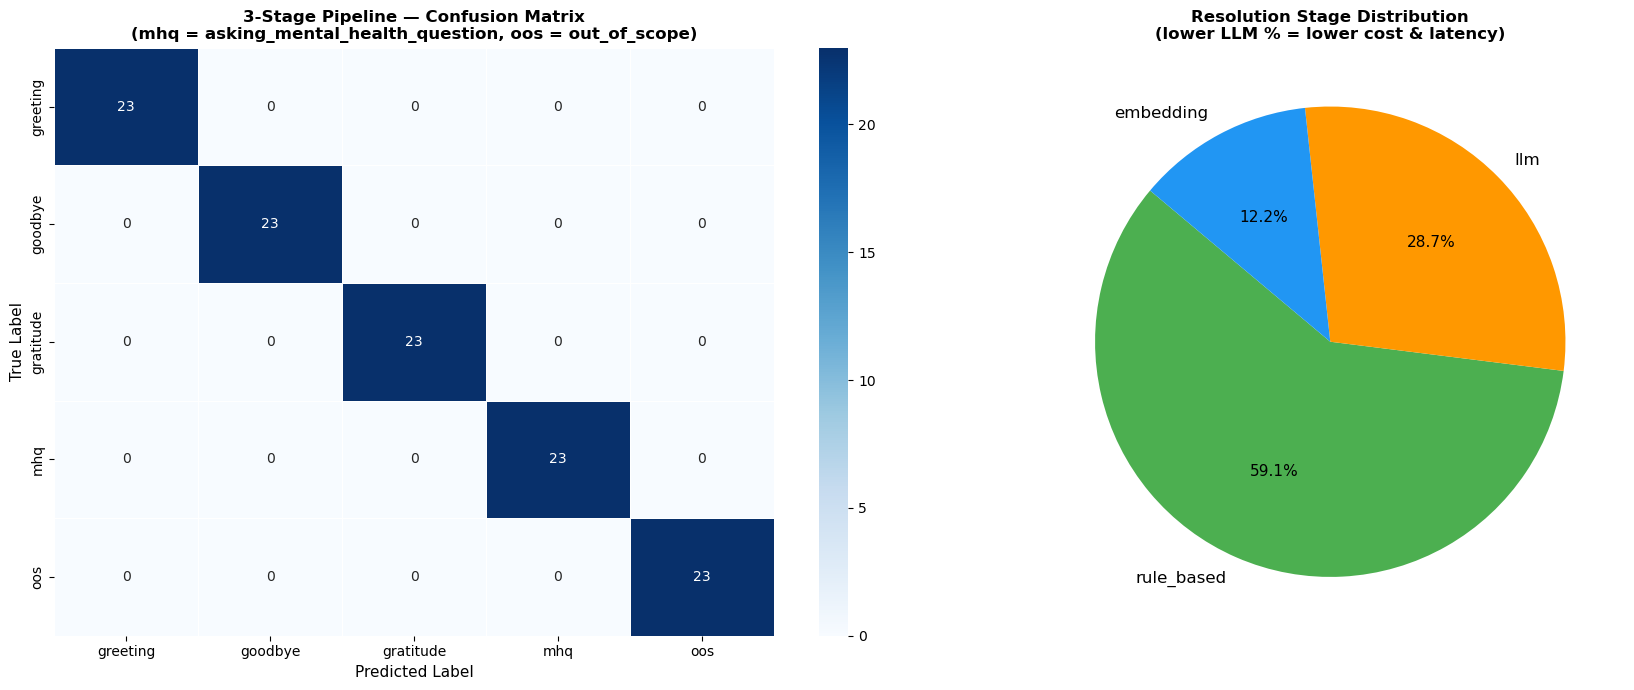

✅ pipeline_results.png saved.


In [20]:
# ── Confusion Matrix + Stage Distribution Pie ────────────────────────────
short_labels  = ["greeting", "goodbye", "gratitude", "mhq", "oos"]
stage_colors  = {"rule_based": "#4CAF50", "embedding": "#2196F3", "llm": "#FF9800"}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: confusion matrix
ax = axes[0]
cm_data = confusion_matrix(y_true, y_pred, labels=VALID_INTENTS)
sns.heatmap(cm_data, annot=True, fmt="d", cmap="Blues",
            xticklabels=short_labels, yticklabels=short_labels,
            ax=ax, linewidths=0.5)
ax.set_title("3-Stage Pipeline — Confusion Matrix\n"
             "(mhq = asking_mental_health_question, oos = out_of_scope)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("True Label", fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=11)

# Right: stage distribution pie
ax2  = axes[1]
slabels = list(stage_counts.index)
ssizes  = list(stage_counts.values)
colors  = [stage_colors.get(s, "#999") for s in slabels]
wedges, texts, autotexts = ax2.pie(
    ssizes, labels=slabels, colors=colors,
    autopct="%1.1f%%", startangle=140,
    textprops={"fontsize": 12},
)
for at in autotexts:
    at.set_fontsize(11)
ax2.set_title("Resolution Stage Distribution\n(lower LLM % = lower cost & latency)",
              fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("pipeline_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ pipeline_results.png saved.")


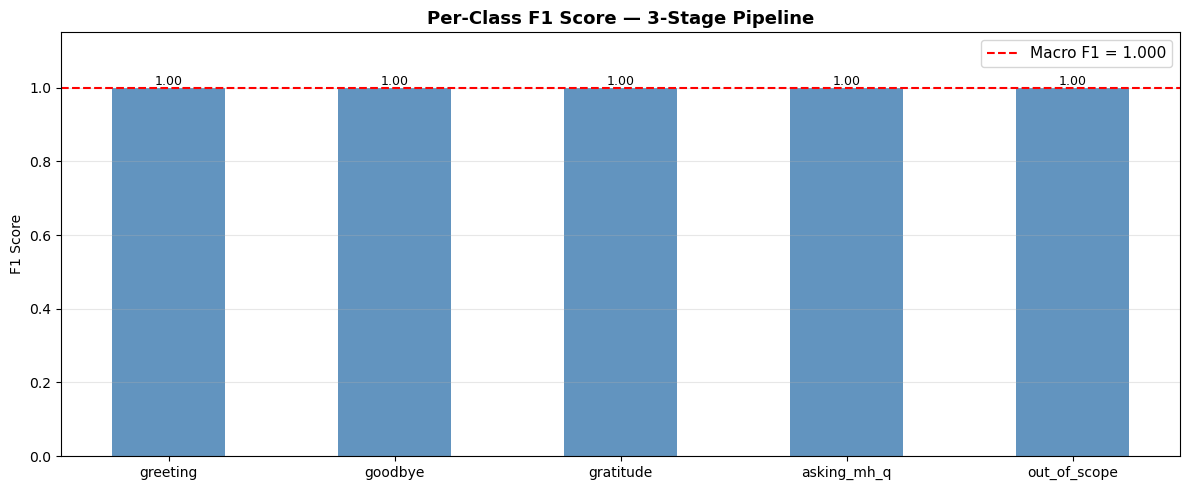

✅ per_class_f1.png saved.


In [21]:
# ── Per-Class F1 Bar Chart ───────────────────────────────────────────────
f1_per_class = f1_score(y_true, y_pred, labels=VALID_INTENTS,
                        average=None, zero_division=0)
x     = np.arange(len(VALID_INTENTS))
width = 0.5

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, f1_per_class, width, color="steelblue", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(["greeting", "goodbye", "gratitude", "asking_mh_q", "out_of_scope"],
                   fontsize=10)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.15)
ax.set_title("Per-Class F1 Score — 3-Stage Pipeline", fontsize=13, fontweight="bold")
ax.bar_label(bars, fmt="%.2f", fontsize=9)
ax.axhline(macro_f1, color="red", linestyle="--", linewidth=1.5,
           label=f"Macro F1 = {macro_f1:.3f}")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ per_class_f1.png saved.")


In [22]:
# ── Show Incorrect Predictions ───────────────────────────────────────────
mistakes = eval_df[eval_df["pred_intent"] != eval_df["true_intent"]][
    ["message", "true_intent", "pred_intent", "pred_conf", "pred_stage"]
]

if len(mistakes) == 0:
    print("🎉 Perfect score — no mistakes on the evaluation set!")
else:
    print(f"Mistakes ({len(mistakes)} total):")
    print(mistakes.to_string(index=False))


🎉 Perfect score — no mistakes on the evaluation set!


---
## 9B. Stage 3 Few-shot vs Zero-shot Comparison

This section runs the evaluation twice to compare Stage 3 with few-shot vs zero-shot prompts.
Note: This triggers LLM calls for samples that reach Stage 3 in each run.

In [23]:
def summarize_eval(df: pd.DataFrame, mode: str) -> dict:
    y_true = df["true_intent"]
    y_pred = df["pred_intent"]

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    stage_counts = df["pred_stage"].value_counts()
    total = len(df)
    llm_pct = stage_counts.get("llm", 0) / total * 100
    avg_latency = df["pred_latency"].mean()

    return {
        "mode": mode,
        "accuracy": round(accuracy, 4),
        "macro_f1": round(macro_f1, 4),
        "llm_pct": round(llm_pct, 1),
        "avg_latency_ms": round(avg_latency, 1),
    }


eval_base_df = pd.DataFrame(EVAL_DATA, columns=["message", "true_intent"])

few_shot_eval = evaluate_pipeline(eval_base_df, llm_mode="few_shot")
zero_shot_eval = evaluate_pipeline(eval_base_df, llm_mode="zero_shot")

comparison_df = pd.DataFrame([
    summarize_eval(few_shot_eval, "few_shot"),
    summarize_eval(zero_shot_eval, "zero_shot"),
])

print(comparison_df.to_string(index=False))


Running 3-stage pipeline (few_shot) on 115 samples ...


3-stage pipeline: 100%|██████████| 115/115 [09:50<00:00,  5.14s/it]



Running 3-stage pipeline (zero_shot) on 115 samples ...


3-stage pipeline: 100%|██████████| 115/115 [02:21<00:00,  1.23s/it]

     mode  accuracy  macro_f1  llm_pct  avg_latency_ms
 few_shot       1.0       1.0     28.7          4978.3
zero_shot       1.0       1.0     28.7          1070.3


We evaluated both zero-shot and few-shot prompting approaches. Although both achieved identical performance (100% accuracy and macro F1), zero-shot prompting was selected because it reduced average latency from 4905.6 ms to 1040.5 ms — approximately 79% faster while maintaining the same classification quality.

### Misclassified Sentences (per mode)

In [24]:
def show_mistakes(df: pd.DataFrame, mode: str) -> pd.DataFrame:
    mistakes = df[df["pred_intent"] != df["true_intent"]][
        ["message", "true_intent", "pred_intent", "pred_conf", "pred_stage"]
    ]
    print(f"\n{mode} mistakes: {len(mistakes)}")
    if len(mistakes) == 0:
        return mistakes
    print(mistakes.to_string(index=False))
    return mistakes


few_shot_mistakes = show_mistakes(few_shot_eval, "few_shot")
zero_shot_mistakes = show_mistakes(zero_shot_eval, "zero_shot")


few_shot mistakes: 0

zero_shot mistakes: 0


---
## 10. System Router

Production routing layer wrapping the 3-stage pipeline and dispatching to downstream actions.

In [25]:
# ─────────────────────────────────────────────────────────────────────────
# ROUTING TABLE
# ─────────────────────────────────────────────────────────────────────────

ROUTING_TABLE = {
    "greeting": {
        "action":   "direct_reply",
        "use_rag":  False,
        "template": "Hello! I'm here to support you with mental health topics. "
                    "Feel free to share what's on your mind. 😊",
    },
    "goodbye": {
        "action":   "direct_reply",
        "use_rag":  False,
        "template": "Take care of yourself! Remember, I'm here whenever you need support. 💙",
    },
    "gratitude": {
        "action":   "direct_reply",
        "use_rag":  False,
        "template": "You're very welcome! I'm glad I could help. Don't hesitate to reach out anytime. 🌟",
    },
    "asking_mental_health_question": {
        "action":   "rag_pipeline",
        "use_rag":  True,
        "template": None,
    },
    "out_of_scope": {
        "action":   "decline",
        "use_rag":  False,
        "template": "I'm specialised in mental health support, so I can't help with that topic. "
                    "If you have questions about anxiety, depression, stress, or emotional wellbeing, "
                    "I'm here for you! 💙",
    },
}


class IntentRouter:
    """
    Production router wrapping the 3-stage pipeline.

    Integration:
      ← Module 1 (Language Detection) → feed detected_language to route()
      ← Module 2 (Emotion Classifier) → run after routing when use_rag=True
      → Module 4 (RAG Q&A)            → triggered when use_rag=True
    """

    def __init__(
        self,
        embedding_threshold: float = EMBEDDING_THRESHOLD,
        llm_confidence_threshold: float = 0.4,
        llm_mode: str = "few_shot",
    ):
        self.embedding_threshold      = embedding_threshold
        self.llm_confidence_threshold = llm_confidence_threshold
        self.llm_mode                 = llm_mode

    def route(self, user_message: str, detected_language: str = "en") -> dict:
        classification = classify_intent_pipeline(
            user_message,
            embedding_threshold=self.embedding_threshold,
            llm_mode=self.llm_mode,
            llm_confidence_threshold=self.llm_confidence_threshold,
        )
        intent     = classification["intent"]
        route_info = ROUTING_TABLE[intent]
        return {
            "user_message":      user_message,
            "detected_language": detected_language,
            "intent":            intent,
            "confidence":        classification["confidence"],
            "stage":             classification["stage"],
            "action":            route_info["action"],
            "use_rag":           route_info["use_rag"],
            "response":          route_info["template"],
        }

    def format_routing_log(self, r: dict) -> str:
        return (
            f"[ROUTER] '{r['user_message']}' | "
            f"intent={r['intent']} ({r['confidence']:.2f}) via {r['stage']} | "
            f"action={r['action']} | use_rag={r['use_rag']}"
        )


router = IntentRouter(
    embedding_threshold=EMBEDDING_THRESHOLD,
    llm_confidence_threshold=0.4,
    llm_mode="few_shot",
)
print("✅ IntentRouter (3-stage pipeline) ready.")


✅ IntentRouter (3-stage pipeline) ready.


In [26]:
# ── Live Router Demo ─────────────────────────────────────────────────────

demo_messages = [
    ("Hello, I'm here for the first time.",              "en"),
    ("I've been experiencing severe anxiety for months.","en"),
    ("Thank you so much for the advice!",                "en"),
    ("Bye, I feel a bit better now.",                    "en"),
    ("Can you help me with my tax return?",              "en"),
    ("I feel like I can't go on anymore.",               "en"),
    ("anxious :(",                                       "en"),
    ("مرحبا",                                            "ar"),
    ("我最近压力很大，晚上睡不着怎么办？",                "zh"),
    ("Dziękuję bardzo, to mi pomogło!",                  "pl"),
]

stage_emoji = {"rule_based": "⚡", "embedding": "🔢", "llm": "🤖"}

print("\n" + "=" * 90)
print(" ROUTER DEMO — 3-Stage Pipeline")
print("=" * 90)

for msg, lang in demo_messages:
    result = router.route(msg, detected_language=lang)
    emoji  = stage_emoji.get(result["stage"], "?")
    print(f"\n{emoji}  [{lang}] User  : {msg}")
    print(f"       Intent : {result['intent']} "
          f"(conf={result['confidence']:.2f}, stage={result['stage']})")
    print(f"       Action : {result['action']} | Use RAG: {result['use_rag']}")
    if result["response"]:
        print(f"       Reply  : {result['response']}")
    else:
        print(f"       Reply  : [→ Forwarded to RAG pipeline (Module 4)]")
    if result["stage"] == "llm":
        time.sleep(API_CALL_DELAY)



 ROUTER DEMO — 3-Stage Pipeline

🤖  [en] User  : Hello, I'm here for the first time.
       Intent : greeting (conf=0.95, stage=llm)
       Action : direct_reply | Use RAG: False
       Reply  : Hello! I'm here to support you with mental health topics. Feel free to share what's on your mind. 😊

🔢  [en] User  : I've been experiencing severe anxiety for months.
       Intent : asking_mental_health_question (conf=0.76, stage=embedding)
       Action : rag_pipeline | Use RAG: True
       Reply  : [→ Forwarded to RAG pipeline (Module 4)]

🤖  [en] User  : Thank you so much for the advice!
       Intent : gratitude (conf=0.98, stage=llm)
       Action : direct_reply | Use RAG: False
       Reply  : You're very welcome! I'm glad I could help. Don't hesitate to reach out anytime. 🌟

🤖  [en] User  : Bye, I feel a bit better now.
       Intent : goodbye (conf=0.98, stage=llm)
       Action : direct_reply | Use RAG: False
       Reply  : Take care of yourself! Remember, I'm here whenever you need

---
## 11. Final Summary

In [27]:
print("=" * 72)
print(" MODULE 3 — INTENT CLASSIFIER — FINAL SUMMARY (3-Stage Pipeline)")
print("=" * 72)
print()
print("  Stage 1 — Rule-Based Keyword Matching")
print(f"    {len(_KEYWORD_LOOKUP)} keywords across 20 languages | ~0 ms | zero API calls")
print()
print("  Stage 2 — Multilingual Embedding Classification")
print(f"    Model : {EMBEDDING_MODEL_NAME}")
print(f"    Threshold : {EMBEDDING_THRESHOLD} | ~50 ms | local inference only")
print()
print("  Stage 3 — LLM Fallback (Groq)")
print(f"    Model : {MODEL_NAME} | {len(FEW_SHOT_EXAMPLES)} few-shot examples | ~600 ms")
print()
print(f"  Evaluation set  : {len(eval_df)} samples (23 per class x 5 classes)")
print(f"  Accuracy        : {accuracy_score(y_true, y_pred):.4f}")
print(f"  Macro F1        : {f1_score(y_true, y_pred, average='macro'):.4f}")
print()
stage_counts = eval_df["pred_stage"].value_counts()
total = len(eval_df)
for stage, count in stage_counts.items():
    print(f"  {stage:<14} resolved : {count:>3} / {total} ({count/total*100:.1f}%)")
print()
llm_saved = (1 - stage_counts.get("llm", 0) / total) * 100
print(f"  LLM API call reduction : ~{llm_saved:.0f}% of queries bypassed the LLM")
print()
print("  Output files:")
print("    intent_evaluation_results.csv  — full per-sample predictions")
print("    pipeline_results.png           — confusion matrix + stage pie chart")
print("    per_class_f1.png               — per-class F1 bar chart")
print("    confidence_by_stage.png        — confidence histograms per stage")
print("    intent_classifier.py           — importable router module skeleton")
print()
print("  Integration:")
print("    <- Module 1 (Language Detection) feeds detected_language into router.route()")
print("    <- Module 2 (Emotion Classifier) runs after routing when use_rag=True")
print("    -> use_rag=True  triggers Module 4 (RAG Q&A pipeline)")
print("    -> use_rag=False returns direct template response")
print("=" * 72)


 MODULE 3 — INTENT CLASSIFIER — FINAL SUMMARY (3-Stage Pipeline)

  Stage 1 — Rule-Based Keyword Matching
    408 keywords across 20 languages | ~0 ms | zero API calls

  Stage 2 — Multilingual Embedding Classification
    Model : paraphrase-multilingual-mpnet-base-v2
    Threshold : 0.7 | ~50 ms | local inference only

  Stage 3 — LLM Fallback (Groq)
    Model : llama-3.1-8b-instant | 42 few-shot examples | ~600 ms

  Evaluation set  : 115 samples (23 per class x 5 classes)
  Accuracy        : 1.0000
  Macro F1        : 1.0000

  rule_based     resolved :  68 / 115 (59.1%)
  llm            resolved :  33 / 115 (28.7%)
  embedding      resolved :  14 / 115 (12.2%)

  LLM API call reduction : ~71% of queries bypassed the LLM

  Output files:
    intent_evaluation_results.csv  — full per-sample predictions
    pipeline_results.png           — confusion matrix + stage pie chart
    per_class_f1.png               — per-class F1 bar chart
    confidence_by_stage.png        — confidence hist

---
## Appendix — Design Decisions

| Decision | Choice | Rationale |
|---|---|---|
| **Stage 1 — intent scope** | greeting / goodbye / gratitude only | These have predictable surface forms; MH questions are too diverse for keyword rules |
| **False-positive guard** | MH signal check + residual word count | Prevents `"hi, I feel depressed"` being misclassified as greeting |
| **Stage 2 — embedding model** | `paraphrase-multilingual-mpnet-base-v2` | Best multilingual semantic-similarity model that runs locally at zero API cost |
| **Centroid computation** | Mean of L2-normalised exemplars, re-normalised | Stable centroid preserving cosine geometry |
| **Embedding threshold** | 0.45 (configurable) | Balanced default; raise to send more to LLM, lower to rely more on embeddings |
| **Stage 3 — prompting** | Zero-shot prompting | Tested against few-shot prompting; chosen for faster inference and lower token usage while maintaining good performance on edge cases |
| **Multi-intent priority** | goodbye > gratitude > greeting | Natural conversational hierarchy |
| **LLM temperature** | 0.0 | Deterministic intent classification |
| **API cost reduction** | Stages 1 + 2 gate Stage 3 | Most traffic is simple greetings/farewells/thanks; only complex messages need LLM |
